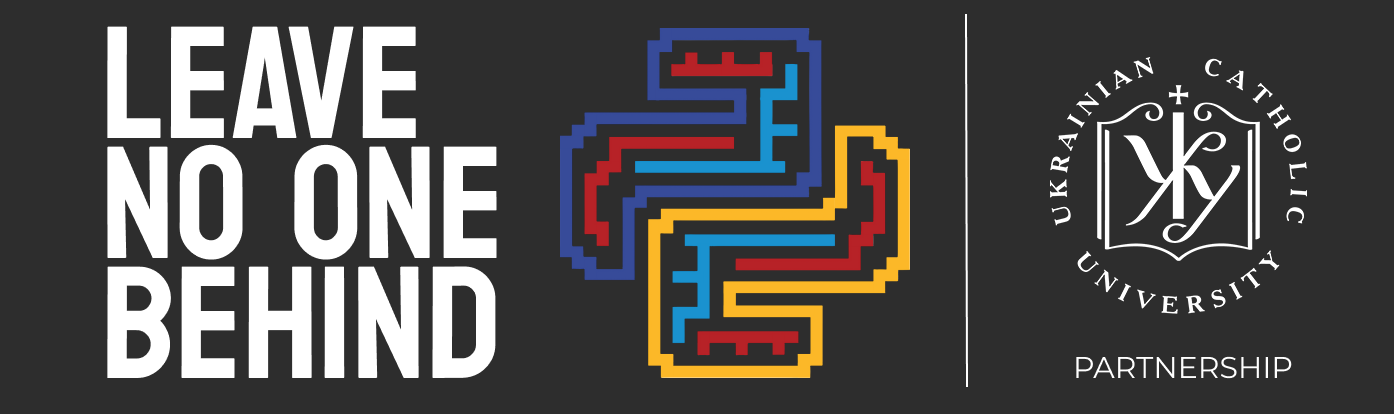

Перед Вами версія 1.0 навчальних матеріалів, що були створені командою Факультету прикладних наук Українського католицького університету в рамках освітнього проєкту ["Не залишити нікого осторонь"](https://www.facebook.com/leavenoonebehindpartnership/) у липні 2024 року. Ми - Радомир Гусєв, Лідія Семсічко, Антон Валігурський, Максим Жук, Тетяна Захарченко -- створювали його з любовʼю. Будемо вдячні, якщо наша праця буде завжди мати вказане авторство. Ліцензовано під [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)

Чарівного Вам кодування!

# Керування потоком виконання. Частина 3.1: try-except

## Зміст

- [1. Помилки й винятки](#errors-exceptions)
- [2. Обробка винятку](#error-handling)
- [3. Обробка кількох винятків](#multiple-except)
- [4. `except ... as`](#except-as)
- [5. `try-else`](#try-else)
- [6. `Exception`](#exception)
- [7. `finally`](#finally)

<a id="errors-exceptions"></a>
## 1. Помилки й винятки

Ми вже стикалися з різними ситуаціями, коли код не працював - Python зупиняв роботу та виводив повідомлення, що на певному рядку щось пішло не так. Такі випадки можна поділити на два:
- синтаксичні помилки (`SyntaxError`),
- винятки.

Синтаксичні помилки - це помилки, через які код навіть не запуститься, наприклад:
- Незакриті лапки чи дужки

In [2]:
print("Never)

SyntaxError: unterminated string literal (detected at line 1) (61762009.py, line 1)

- Відсутні обов'язкові частини конструкцій

In [5]:
if:
    print("gonna")

SyntaxError: invalid syntax (2590963083.py, line 1)

- Чи інші незрозумілі інтерпретатору речі

In [6]:
if True print("give"):

SyntaxError: invalid syntax (1208250583.py, line 1)

Такі неточності не дозволяють навіть почати запускати файл, тож `SyntaxError` виникає ще до запуску програми.

Винятки ж виникають посеред виконання програми. Якщо вони трапляються, це означає, що синтаксично все правильно, просто не має сенсу. Наприклад, `TypeError` (використання типів, які не підтримуються):

In [7]:
2 + "Hello"

TypeError: unsupported operand type(s) for +: 'int' and 'str'

У цьому випадку Python каже, що не можна виконувати додавання між цілим числом та стрічкою.

За аналогією з українською мовою:
- У реченні "пес спекла роки чорний тому" слова навіть не узгоджуються &mdash; синтаксична помилка;
- Речення "два плюс будинок дорівнює чотири" ж не має сенсу (додавання двійки до будинку), але слова узгоджуються &mdash; виняток.

Є багато різних винятків, і навіть можна створювати свої. Однак вони всі з'являються під час виконання програми. Наведемо ще кілька прикладів:

- Ділення на нуль (`ZeroDivisionError`)

In [9]:
print(2 or 1/0)
print(1/0 or 2)

2


ZeroDivisionError: division by zero

- Використання назв неіснуючих функцій, змінних (`NameError`)

In [10]:
prnt(2)

NameError: name 'prnt' is not defined

<a id="error-handling"></a>
## 2. Обробка винятку

На синтаксичні помилки ніяк не вийде зробити перевірку під час запуску програми (ні через які `if` чи інші конструкції), адже вони виникають ще до запуску коду.

Винятки ж можна обробляти протягом виконання коду. Для цього використовують конструкцію `try-except`:

In [13]:
try:
    print("Початок")
    print(1/0)
except ZeroDivisionError:
    print("Ви спробували поділити на нуль")

print("Кінець")

Початок
Ви спробували поділити на нуль
Кінець


Усе, що знаходиться усередині `try`-блоку виконається звично, але якщо під час виконання у блоці виникне виняток `ZeroDivisionError`, то почне виконуватися код у блоці `except`. Код поза цими блоками працює так само, як і раніше.

Немає нічого специфічного щодо `ZeroDivisionError`, і будь-який виняток можна перехопити через `except`:

In [15]:
try:
    print(Hello, world)
except NameError:
    print("Змінної не існує")

Змінної не існує


Але якщо виникне помилка, не зазначена в конструкції `except`, то вона закінчить програму так, наче `try` і не було:

In [16]:
try:
    1/0
except NameError:
    print("Змінної не існує")

ZeroDivisionError: division by zero

<a id="multiple-except"></a>
## 3. Обробка кількох винятків

Однак можна задавати кілька блоків `except`, кожен з яких буде відповідати за свої помилки:

In [19]:
try:
    print("Початок")
    print(1/0) # 1
    prnt(2) # 2
except ZeroDivisionError:
    print("Ви спробували поділити на нуль")
except NameError:
    print("Змінної не існує")

print("Кінець")

Початок
Ви спробували поділити на нуль
Кінець


Спробуйте змінити місцями рядки з номерами `# 1` та `# 2` у коді вище.

Якщо ж потрібно зробити однакову дію при кількох винятках, то можна перерахувати у кортежі:

In [25]:
try:
    print("Початок")
    print(1/0)
    prnt(2)
except (ZeroDivisionError, NameError):
    print("Ви спробували поділити на нуль або використали змінну, якої не існує")

print("Кінець")

Початок
Ви спробували поділити на нуль або використали змінну, якої не існує
Кінець


<a id="except-as"></a>
## 4. `except ... as`

Деколи може бути бажання отримати певну інформацію з винятку (як-от повідомлення про помилку). Для такого можна додати `... as <назва змінної` до кінця рядка `except...`:

In [2]:
try:
    1/0
except ZeroDivisionError as error:
    print(error)
    
print("Програма далі виконується")

division by zero
Програма далі виконується


У частині `... as <назва_змінної>` ми створюємо змінну, в яку запишеться помилка - після цього можемо використовувати її всередині блоку.

<a id="try-else"></a>
## 5. `try-else`

Так само, як з `if`, `for` та `while`, у конструкції `try` можна додавати блок `else`. В умовній конструкції цей блок виконується, якщо умова не справджується; в циклах за умови, що не було виходу через `break`.

У випадку `try` же блок `else` виконується за умови, що не виникало жодних помилок у блоці `try`:

In [10]:
to_divide = 1

try:
    print(1/to_divide)
except ZeroDivisionError:
    print("Ви ділите на 0!")
except TypeError:
    print("Ви передали на той тип даних!")
else:
    print("Не було помилки")

1.0
Не було помилки


Спробуйте замінювати значення змінної `to_divide`:
- Якщо виникне помилка поділу на `0`, то виконається перший `except`;
- якщо, наприклад, присвоїти значення стрічки (як-от `"1"`), то виконається другий блок `except`;
- якщо трапиться ще інша помилка (наприклад, `NameError`), то помилка не перехопиться, і вся програма впаде;
- якщо ж не траплятиметься помилок, то виконання перейде до `else`.

Також зауважмо, що блок `else` має бути розташований після всіх блоків `except` - інакше буде синтаксична помилка:

In [11]:
try:
    print(1/0)
except ZeroDivisionError:
    print("Ви ділите на 0!")
else:
    print("Не було помилки")    
except TypeError:
    print("Ви передали на той тип даних!")

SyntaxError: invalid syntax (1151730989.py, line 7)

<a id="exception"></a>
## 6. `Exception`

Так само, як булеві змінні є також і числами:

In [30]:
print(f"{type(True) = }")
print(f"{type(1) = }")

print()

print(f"{(1 == True) = }")
print(f"{isinstance(True, int) = }")

type(True) = <class 'bool'>
type(1) = <class 'int'>

(1 == True) = True
isinstance(True, int) = True


Так насправді більшість винятків є також і типу `Exception` ([посилання](https://docs.python.org/3/library/exceptions.html#exception-hierarchy), аби переглянути, які винятки від яких походять):

In [1]:
print(isinstance(NameError(), Exception))
print(isinstance(ZeroDivisionError(), Exception))
print(isinstance(TypeError(), Exception))

True
True
True


Тож ліниві програмісти часто люблять просто писати `except Exception`, аби перехоплювати всі помилки:

In [4]:
try:
    print("Початок")
    print(1/0)
    prnt(2)
except Exception:
    print("Ви спробували зробити щось не те (ми не знаємо, що, бо перехоплюємо усе підряд)")

Початок
Ви спробували зробити щось не те (ми не знаємо, що, бо перехоплюємо усе підряд)


Або навіть просто `except:` - такий синтаксис теж дозволений, але він навіть ще більше помилок перехоплює.

In [3]:
try:
    1/0
except:
    print("Якась помилка?")

Якась помилка?


Але у цих методів є великий мінус: ніколи не знаєш, що саме перехоплюєш. Наприклад, якщо так намагатися перехопити потенційні помилки з діленням на нуль, то може статися зовсім не очікуваний результат з іншою помилкою:

In [6]:
try:
    number1 = float(inut("Число 1: "))
    number2 = float(input("Число 2: "))
    print(number1 / number2)
except:
    print("Ви поділили на нуль!")

Ви поділили на нуль!


Нас навіть не питає про числа! Це тому, що при набиранні хтось написав `inut` замість `input`, і виникає `NameError` під час виконання. Але оскільки ми ловимо усі помилки, то навіть не дізнаємося, що проблема саме з написанням, а не діленням на нуль!

Ситуація ще гірша, якщо цикл `while` помістити в такий `try-except`, а потім виявиться, що цикл вийшов вічним, і не може закінчитися. Тоді навіть не вийде зупинити через `Ctrl+c` - бо це викликає `KeyboardInterrupt` помилку, яка захоплюється сирим `except:`

Але показувати це не будемо з метою вбереження Вашої безпеки - можете це зробити самі в терміналі на свій страх і ризик!

<a id="finally"></a>
## 7. `finally`

Врешті поговоримо про `finally`.

Його зазвичай використовують на пізніших стадіях вивчення Python, але знати про його існування таки варто. Блок у `finally` виконається за будь-яких обставин: чи то без пригод закінчився блок `try`, чи то `except`, чи навіть за ще гірших!

In [7]:
try:
    print("Try")
    True or 1/0
except ZeroDivisionError:
    print("Exception")
finally:
    print("Finally")

print("Кінець")

Try
Finally
Кінець


Можете змінювати `True` на `False` &mdash; це викличе виняток, але блок `finally` все одно виконається.

Поки що, однак, це нічим не відрізняється від того, аби просто написати якийсь код після усієї конструкції. `finally` ж використовують в екстремальних ситуаціях: як-от якщо виникне виняток у блоці `except`:

In [9]:
try:
    print("Try")
    True or 1/0
except ZeroDivisionError:
    print("Ви намагалися зробити", 1/0)
finally:
    print("Finally")

print("Кінець")

Try
Finally
Кінець


Як бачимо, у самому блоці, який мав обробляти помилку, сталася помилка! Але блок `finally` виконається навіть у такому випадку.

Є ще деякі ситуації, коли цей блок поводиться інакше, ніж код після конструкції, але вони поки не важливі.

На цьому усе, і чарівного вам кодування!